# Visit 1 – Machine Learning Pipeline

Addresses reviewer comments 30-37. Drops: record_id, injury_mechanism, buckets (+ other non-predictors). Y = buckets.

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix,
    matthews_corrcoef, brier_score_loss
)
from sklearn.model_selection import train_test_split, ParameterSampler
import warnings
warnings.filterwarnings("ignore")
print("Libraries loaded.")


Libraries loaded.


In [3]:
df = pd.read_csv("visit1_3_27_26.csv")
print(df.shape)
df.head(3)


(217, 37)


,Treatment_present,prev_head_injury,import_phq9_score,import_gad7_score,high_total_sx_severity,cerv_flex,cerv_ext,l_lat_flex,r_lat_flex,subocc_flex,...,vor_horiz_fogginess,vor_vert_headache,vor_vert_dizziness,vor_vert_fogginess,vmst_dizziness,vmst_nausea,vmst_fogginess,buckets,record_id,injury_mechanism
0,1,0,17.0,16.0,40.0,60.0,50.0,45.0,45.0,12.0,...,0.0,3.0,1.0,0.0,1.0,1.0,0.0,0,1,2
1,1,0,6.0,2.0,5.0,52.0,42.0,40.0,44.0,12.0,...,0.0,0.0,2.0,0.0,2.0,0.0,0.0,1,10,2
2,1,1,26.0,21.0,114.0,52.0,34.0,21.0,28.0,10.0,...,8.0,8.0,7.0,8.0,8.0,6.0,8.0,1,20,2


In [4]:
print(df["buckets"].value_counts())


buckets
1    176
0     41
Name: count, dtype: int64


In [6]:
# X: explicitly drop record_id, injury_mechanism, buckets, plus other non-predictor columns
cols_X = [
    "buckets", "record_id", "injury_mechanism",
    "days_2_clearance", "days_2_firstvisit",
    "high_total_sx_severity", "redcap_repeat_instance"
]
cols_X = [c for c in cols_X if c in df.columns]

X = df.drop(columns=cols_X)
y = df["buckets"]
print(f"X shape: {X.shape}")
print(f"y distribution:\n{y.value_counts()}")


X shape: (217, 33)
y distribution:
buckets
1    176
0     41
Name: count, dtype: int64


## Comment 30 – EPV Reporting

In [35]:
n_total    = len(df)
n_minority = int(y.value_counts().min())
n_features = X.shape[1]
epv        = n_minority / n_features

print("=" * 50)
print(f"Total N           : {n_total}")
print(f"Minority class N  : {n_minority}")
print(f"Number of features: {n_features}")
print(f"EPV               : {epv:.2f}")
if epv < 10:
    print("WARNING: EPV < 10 – interpret results with caution (risk of overfitting).")
print("=" * 50)


Total N           : 217
Minority class N  : 41
Number of features: 33
EPV               : 1.24


## Shared Helper Functions (Comments 31, 32, 37)

In [9]:
def compute_metrics(y_true, y_pred, y_prob=None, B=1000, random_state=42):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    pts = dict(
        accuracy     = accuracy_score(y_true, y_pred),
        bal_accuracy = balanced_accuracy_score(y_true, y_pred),
        precision    = precision_score(y_true, y_pred, zero_division=0),
        recall       = recall_score(y_true, y_pred, zero_division=0),
        f1           = f1_score(y_true, y_pred, zero_division=0),
        specificity  = specificity,
        mcc          = matthews_corrcoef(y_true, y_pred),
    )
    if y_prob is not None:
        pts["brier"] = brier_score_loss(y_true, y_prob)
    rng = np.random.default_rng(random_state)
    boot = {k: [] for k in pts}
    for _ in range(B):
        idx = rng.integers(0, len(y_true), len(y_true))
        yt, yp = y_true[idx], y_pred[idx]
        tn_b, fp_b, fn_b, tp_b = confusion_matrix(yt, yp, labels=[0, 1]).ravel()
        spec_b = tn_b / (tn_b + fp_b) if (tn_b + fp_b) > 0 else 0.0
        boot["accuracy"].append(accuracy_score(yt, yp))
        boot["bal_accuracy"].append(balanced_accuracy_score(yt, yp))
        boot["precision"].append(precision_score(yt, yp, zero_division=0))
        boot["recall"].append(recall_score(yt, yp, zero_division=0))
        boot["f1"].append(f1_score(yt, yp, zero_division=0))
        boot["specificity"].append(spec_b)
        boot["mcc"].append(matthews_corrcoef(yt, yp))
        if y_prob is not None:
            boot["brier"].append(brier_score_loss(yt, y_prob[idx]))
    cis = {k: (np.percentile(v, 2.5), np.percentile(v, 97.5)) for k, v in boot.items()}
    print("Metric               Point Est   95% CI")
    print("-" * 48)
    for k, val in pts.items():
        lo, hi = cis[k]
        print(f"{k:<20} {val:.4f}      [{lo:.4f}, {hi:.4f}]")
    return pts, cis

def plot_confusion(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    cm_df = pd.DataFrame(cm, index=["Actual 0", "Actual 1"], columns=["Pred 0", "Pred 1"])
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_feature_importance(fi_df, title="Top 20 Feature Importances"):
    top20 = fi_df.head(20).copy()
    plt.figure(figsize=(8, 6))
    plt.barh(top20["feature"][::-1], top20["importance"][::-1], color="steelblue")
    plt.xlabel("Importance")
    plt.title(title)
    plt.tight_layout()
    plt.show()
    return top20

def plot_effect_direction(model, X, top20, title="Average Effect"):
    top_feats = top20["feature"].tolist()
    effects = []
    for f in top_feats:
        med = X[f].median()
        X_hi = X[X[f] > med]
        X_lo = X[X[f] <= med]
        ph = model.predict_proba(X_hi)[:, 1].mean() if not X_hi.empty else 0.0
        pl = model.predict_proba(X_lo)[:, 1].mean() if not X_lo.empty else 0.0
        effects.append({"feature": f, "avg_effect": ph - pl})
    eff_df = pd.DataFrame(effects).sort_values("avg_effect", key=abs, ascending=False)
    colors = eff_df["avg_effect"].apply(lambda v: "red" if v > 0 else "blue")
    plt.figure(figsize=(8, 6))
    plt.barh(eff_df["feature"], eff_df["avg_effect"], color=colors)
    plt.xlabel("Avg Effect on P(prolonged recovery)")
    plt.axvline(0, color="black", lw=0.8)
    plt.title(title)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    return eff_df

print("Helper functions ready.")


Helper functions ready.


In [10]:
n_neg = int((y == 0).sum())
n_pos = int((y == 1).sum())
scale_pos_weight_val = n_neg / n_pos
print(f"Negative: {n_neg}, Positive: {n_pos}, scale_pos_weight: {scale_pos_weight_val:.2f}")


Negative: 41, Positive: 176, scale_pos_weight: 0.23


## LightGBM

In [11]:
import lightgbm as lgb

X_lgbm = df.drop(columns=cols_X)
y_lgbm = df["buckets"]

X_tr, X_te, y_tr, y_te = train_test_split(X_lgbm, y_lgbm, test_size=0.2, random_state=42)

param_dist = {
    "num_leaves":        [31, 50, 70],
    "max_depth":         [-1, 10, 20, 30],
    "learning_rate":     [0.01, 0.05, 0.1, 0.2],
    "n_estimators":      [100, 200, 500, 1000],
    "min_child_samples": [10, 20, 30, 50],
    "subsample":         [0.6, 0.8, 1.0],
    "colsample_bytree":  [0.6, 0.8, 1.0],
}
param_list = list(ParameterSampler(param_dist, n_iter=50, random_state=42))

best_score_lgbm, best_params_lgbm = 0, None
for params in param_list:
    m = lgb.LGBMClassifier(random_state=42, class_weight="balanced", verbose=-1, **params)
    m.fit(X_tr, y_tr)
    acc = balanced_accuracy_score(y_te, m.predict(X_te))
    if acc > best_score_lgbm:
        best_score_lgbm = acc
        best_params_lgbm = params

print("Best params:", best_params_lgbm)
print(f"Best balanced accuracy (hold-out): {best_score_lgbm:.4f}")


Best params: {'subsample': 0.6, 'num_leaves': 70, 'n_estimators': 100, 'min_child_samples': 20, 'max_depth': 30, 'learning_rate': 0.01, 'colsample_bytree': 0.6}
Best balanced accuracy (hold-out): 0.7431


In [14]:
y_true_lgbm, y_pred_lgbm, y_prob_lgbm = [], [], []
fi_sum_lgbm = np.zeros(X_lgbm.shape[1])

for i in range(len(df)):
    Xtr = X_lgbm.drop(index=i)
    ytr = y_lgbm.drop(index=i)
    Xte = X_lgbm.iloc[[i]]
    m = lgb.LGBMClassifier(random_state=42, class_weight="balanced",
                            verbose=-1, **best_params_lgbm)
    m.fit(Xtr, ytr)
    fi_sum_lgbm += m.booster_.feature_importance(importance_type="gain")
    y_pred_lgbm.append(m.predict(Xte)[0])
    y_prob_lgbm.append(m.predict_proba(Xte)[0, 1])
    y_true_lgbm.append(y_lgbm.iloc[i])
    if (i + 1) % 50 == 0 or (i + 1) == len(df):
        print(f"Progress: {i+1}/{len(df)}")

y_true_lgbm = np.array(y_true_lgbm)
y_pred_lgbm = np.array(y_pred_lgbm)
y_prob_lgbm = np.array(y_prob_lgbm)
print("=== LightGBM LOOCV Results (Visit 1) ===")
metrics_lgbm, cis_lgbm = compute_metrics(y_true_lgbm, y_pred_lgbm, y_prob_lgbm)


Progress: 50/217
Progress: 100/217
Progress: 150/217
Progress: 200/217
Progress: 217/217
=== LightGBM LOOCV Results (Visit 1) ===
Metric               Point Est   95% CI
------------------------------------------------
accuracy             0.7373      [0.6820, 0.7972]
bal_accuracy         0.6978      [0.6202, 0.7778]
precision            0.8993      [0.8493, 0.9437]
recall               0.7614      [0.6994, 0.8249]
f1                   0.8246      [0.7791, 0.8693]
specificity          0.6341      [0.4884, 0.7778]
mcc                  0.3338      [0.2004, 0.4723]
brier                0.1884      [0.1720, 0.2038]


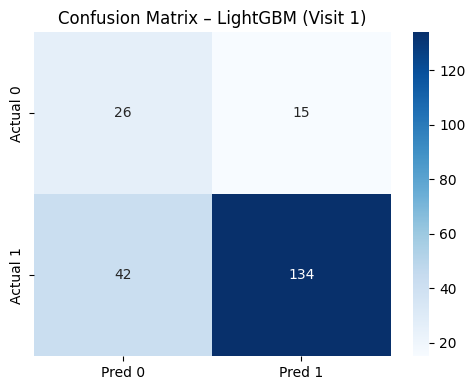

=== Top 20 Features – LightGBM ===
                feature  importance
      Treatment_present  971.662535
             l_cerv_rot  939.104085
              cerv_flex  740.686121
             r_cerv_rot  264.075938
         bess_single_ec  202.076859
     vor_vert_dizziness  141.002521
    vor_horiz_dizziness  133.628647
      import_gad7_score  128.025994
      import_phq9_score  115.570204
            npc_measure  105.399191
            subocc_flex  101.555889
               cerv_ext   97.262057
          voms_headache   89.316164
             subocc_ext   81.572953
             l_lat_flex   75.983350
             r_lat_flex   72.269857
     vor_horiz_headache   71.551055
         bess_tandem_ec   59.905394
smoothpursuits_headache   51.673247
saccades_horiz_headache   33.502085


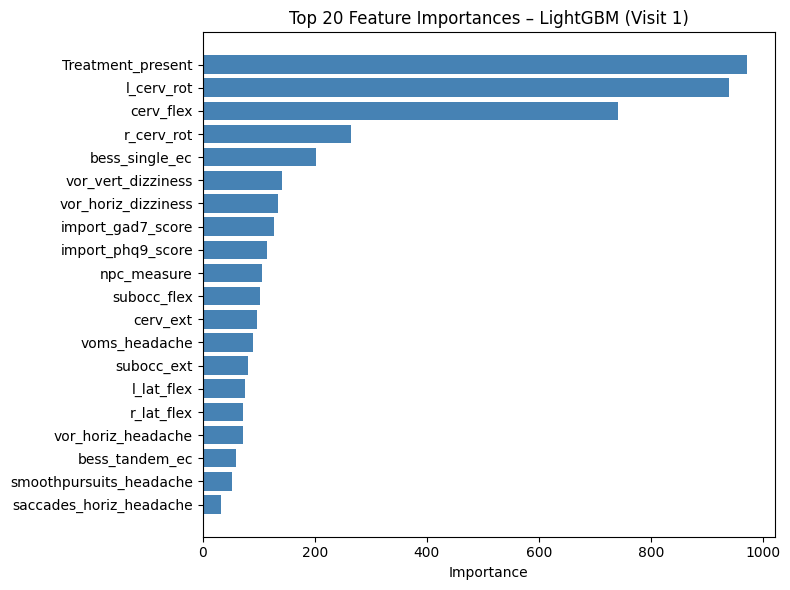

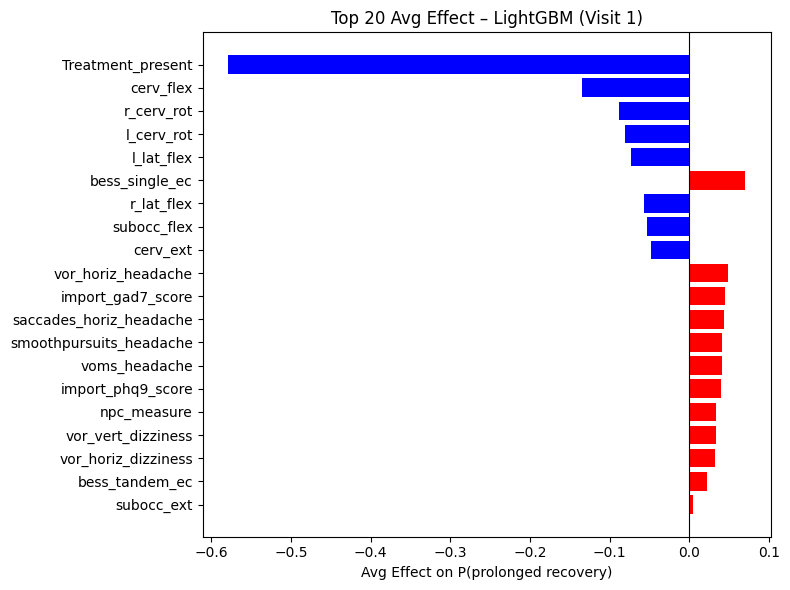

,feature,avg_effect
0,Treatment_present,-0.578283
2,cerv_flex,-0.134231
3,r_cerv_rot,-0.088479
1,l_cerv_rot,-0.081460
14,l_lat_flex,-0.073923
4,bess_single_ec,0.070226
15,r_lat_flex,-0.056680
10,subocc_flex,-0.052960
11,cerv_ext,-0.047966
16,vor_horiz_headache,0.047904


In [15]:
plot_confusion(y_true_lgbm, y_pred_lgbm, "Confusion Matrix – LightGBM (Visit 1)")
fi_df_lgbm = (pd.DataFrame({"feature": X_lgbm.columns, "importance": fi_sum_lgbm / len(df)})
              .sort_values("importance", ascending=False))
print("=== Top 20 Features – LightGBM ===")
print(fi_df_lgbm.head(20).to_string(index=False))
top20_lgbm = plot_feature_importance(fi_df_lgbm, "Top 20 Feature Importances – LightGBM (Visit 1)")
_m_lgbm = lgb.LGBMClassifier(random_state=42, class_weight="balanced",
                               verbose=-1, **best_params_lgbm).fit(X_lgbm, y_lgbm)
plot_effect_direction(_m_lgbm, X_lgbm, top20_lgbm, "Top 20 Avg Effect – LightGBM (Visit 1)")


## Decision Tree

In [16]:
from sklearn.tree import DecisionTreeClassifier

X_dt = df.drop(columns=cols_X)
y_dt = df["buckets"]

X_tr, X_te, y_tr, y_te = train_test_split(X_dt, y_dt, test_size=0.2, random_state=42)
param_dist_dt = {
    "criterion":        ["gini", "entropy", "log_loss"],
    "max_depth":        [None, 10, 20, 30, 50],
    "min_samples_split":[2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_features":     [None, "sqrt", "log2"],
    "splitter":         ["best", "random"],
}
param_list_dt = list(ParameterSampler(param_dist_dt, n_iter=50, random_state=42))

best_score_dt, best_params_dt = 0, None
for params in param_list_dt:
    m = DecisionTreeClassifier(random_state=42, class_weight="balanced", **params)
    m.fit(X_tr, y_tr)
    acc = balanced_accuracy_score(y_te, m.predict(X_te))
    if acc > best_score_dt:
        best_score_dt = acc
        best_params_dt = params

print("Best params:", best_params_dt)
print(f"Best balanced accuracy: {best_score_dt:.4f}")


Best params: {'splitter': 'random', 'min_samples_split': 20, 'min_samples_leaf': 5, 'max_features': None, 'max_depth': 20, 'criterion': 'entropy'}
Best balanced accuracy: 0.8542


In [17]:
y_true_dt, y_pred_dt, y_prob_dt = [], [], []
fi_sum_dt = np.zeros(X_dt.shape[1])
for i in range(len(df)):
    Xtr = X_dt.drop(index=i)
    ytr = y_dt.drop(index=i)
    Xte = X_dt.iloc[[i]]
    m = DecisionTreeClassifier(random_state=42, class_weight="balanced", **best_params_dt)
    m.fit(Xtr, ytr)
    fi_sum_dt += m.feature_importances_
    y_pred_dt.append(m.predict(Xte)[0])
    y_prob_dt.append(m.predict_proba(Xte)[0, 1])
    y_true_dt.append(y_dt.iloc[i])
    if (i + 1) % 50 == 0 or (i + 1) == len(df):
        print(f"Progress: {i+1}/{len(df)}")
y_true_dt, y_pred_dt, y_prob_dt = np.array(y_true_dt), np.array(y_pred_dt), np.array(y_prob_dt)
print("=== Decision Tree LOOCV Results (Visit 1) ===")
metrics_dt, cis_dt = compute_metrics(y_true_dt, y_pred_dt, y_prob_dt)


Progress: 50/217
Progress: 100/217
Progress: 150/217
Progress: 200/217
Progress: 217/217
=== Decision Tree LOOCV Results (Visit 1) ===
Metric               Point Est   95% CI
------------------------------------------------
accuracy             0.6313      [0.5714, 0.6959]
bal_accuracy         0.6137      [0.5358, 0.6920]
precision            0.8692      [0.8047, 0.9224]
recall               0.6420      [0.5698, 0.7143]
f1                   0.7386      [0.6824, 0.7925]
specificity          0.5854      [0.4390, 0.7400]
mcc                  0.1816      [0.0561, 0.3036]
brier                0.2375      [0.1973, 0.2780]


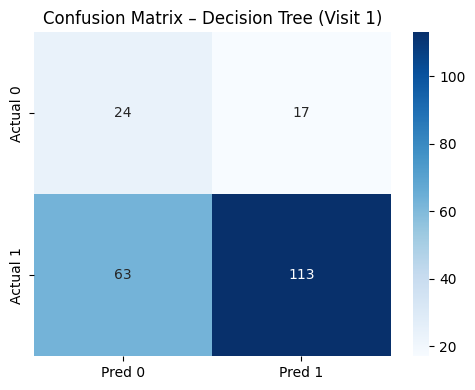

=== Top 20 Features – Decision Tree ===
                 feature  importance
       Treatment_present    0.203354
 saccades_horiz_headache    0.158324
              l_cerv_rot    0.134539
          voms_dizziness    0.118795
     vor_horiz_dizziness    0.117634
              subocc_ext    0.055111
          bess_single_ec    0.052189
             voms_nausea    0.037471
          vmst_fogginess    0.024157
 smoothpursuits_headache    0.022680
             npc_measure    0.020193
             subocc_flex    0.012921
               cerv_flex    0.007770
              r_cerv_rot    0.006600
          bess_tandem_ec    0.003402
            npc_headache    0.003039
      vor_vert_dizziness    0.002944
        prev_head_injury    0.002648
       vor_vert_headache    0.002425
smoothpursuits_dizziness    0.002423


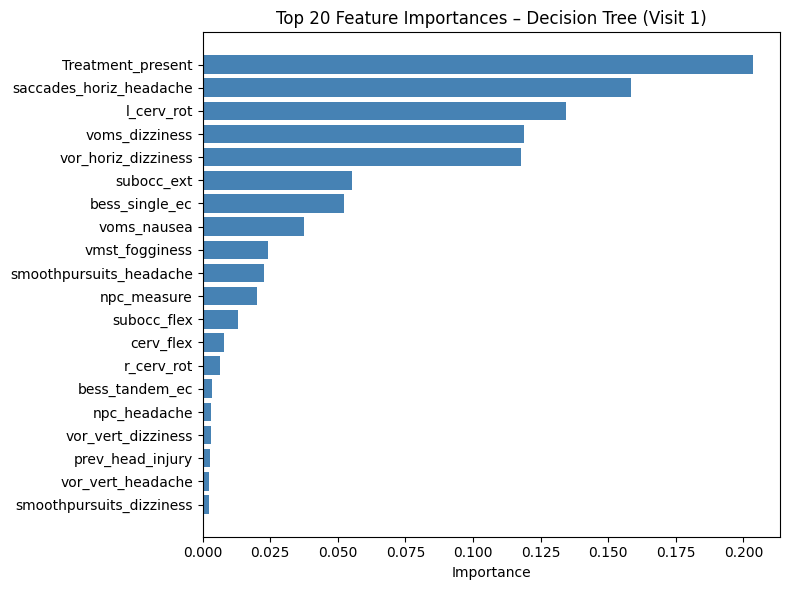

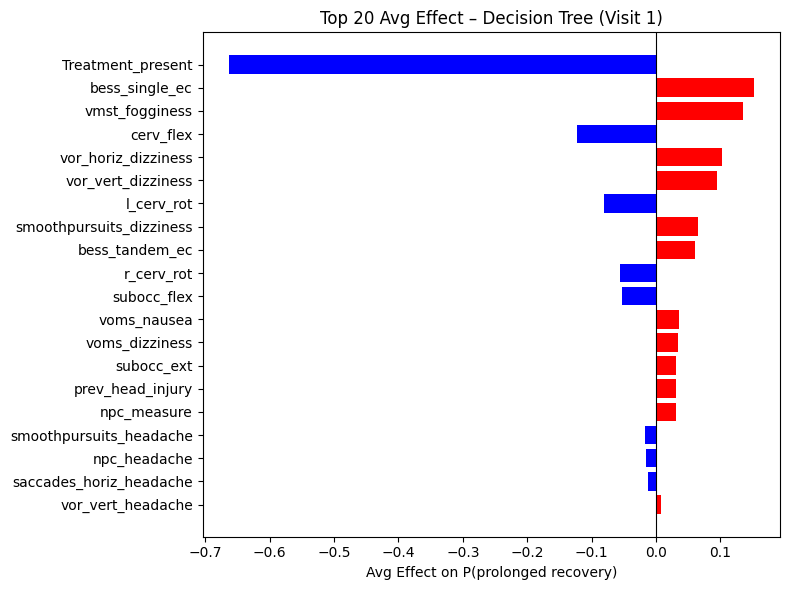

,feature,avg_effect
0,Treatment_present,-0.663362
6,bess_single_ec,0.151796
8,vmst_fogginess,0.135477
12,cerv_flex,-0.123251
4,vor_horiz_dizziness,0.103091
16,vor_vert_dizziness,0.095358
2,l_cerv_rot,-0.080206
19,smoothpursuits_dizziness,0.065289
14,bess_tandem_ec,0.061219
13,r_cerv_rot,-0.055694


In [18]:
plot_confusion(y_true_dt, y_pred_dt, "Confusion Matrix – Decision Tree (Visit 1)")
fi_df_dt = (pd.DataFrame({"feature": X_dt.columns, "importance": fi_sum_dt / len(df)})
             .sort_values("importance", ascending=False))
print("=== Top 20 Features – Decision Tree ===")
print(fi_df_dt.head(20).to_string(index=False))
top20_dt = plot_feature_importance(fi_df_dt, "Top 20 Feature Importances – Decision Tree (Visit 1)")
_m_dt = DecisionTreeClassifier(random_state=42, class_weight="balanced", **best_params_dt).fit(X_dt, y_dt)
plot_effect_direction(_m_dt, X_dt, top20_dt, "Top 20 Avg Effect – Decision Tree (Visit 1)")


## Random Forest

In [19]:
from sklearn.ensemble import RandomForestClassifier

X_rf = df.drop(columns=cols_X)
y_rf = df["buckets"]
X_tr, X_te, y_tr, y_te = train_test_split(X_rf, y_rf, test_size=0.2, random_state=42)

param_dist_rf = {
    "criterion":        ["gini", "entropy"],
    "max_depth":        [None, 10, 20, 30, 50],
    "min_samples_split":[2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_features":     [None, "sqrt", "log2"],
}
param_list_rf = list(ParameterSampler(param_dist_rf, n_iter=50, random_state=42))
best_score_rf, best_params_rf = 0, None
for params in param_list_rf:
    m = RandomForestClassifier(random_state=42, class_weight="balanced", **params)
    m.fit(X_tr, y_tr)
    acc = balanced_accuracy_score(y_te, m.predict(X_te))
    if acc > best_score_rf:
        best_score_rf = acc
        best_params_rf = params
print("Best params:", best_params_rf)
print(f"Best balanced accuracy: {best_score_rf:.4f}")


Best params: {'min_samples_split': 20, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 20, 'criterion': 'entropy'}
Best balanced accuracy: 0.6111


In [20]:
y_true_rf, y_pred_rf, y_prob_rf = [], [], []
fi_sum_rf = np.zeros(X_rf.shape[1])
for i in range(len(df)):
    Xtr = X_rf.drop(index=i)
    ytr = y_rf.drop(index=i)
    Xte = X_rf.iloc[[i]]
    m = RandomForestClassifier(random_state=42, class_weight="balanced", **best_params_rf)
    m.fit(Xtr, ytr)
    fi_sum_rf += m.feature_importances_
    y_pred_rf.append(m.predict(Xte)[0])
    y_prob_rf.append(m.predict_proba(Xte)[0, 1])
    y_true_rf.append(y_rf.iloc[i])
    if (i + 1) % 50 == 0 or (i + 1) == len(df):
        print(f"Progress: {i+1}/{len(df)}")
y_true_rf, y_pred_rf, y_prob_rf = np.array(y_true_rf), np.array(y_pred_rf), np.array(y_prob_rf)
print("=== Random Forest LOOCV Results (Visit 1) ===")
metrics_rf, cis_rf = compute_metrics(y_true_rf, y_pred_rf, y_prob_rf)


Progress: 50/217
Progress: 100/217
Progress: 150/217
Progress: 200/217
Progress: 217/217
=== Random Forest LOOCV Results (Visit 1) ===
Metric               Point Est   95% CI
------------------------------------------------
accuracy             0.7742      [0.7189, 0.8295]
bal_accuracy         0.5802      [0.5080, 0.6560]
precision            0.8396      [0.7821, 0.8912]
recall               0.8920      [0.8439, 0.9375]
f1                   0.8650      [0.8262, 0.9003]
specificity          0.2683      [0.1400, 0.4151]
mcc                  0.1818      [0.0198, 0.3355]
brier                0.1682      [0.1470, 0.1909]


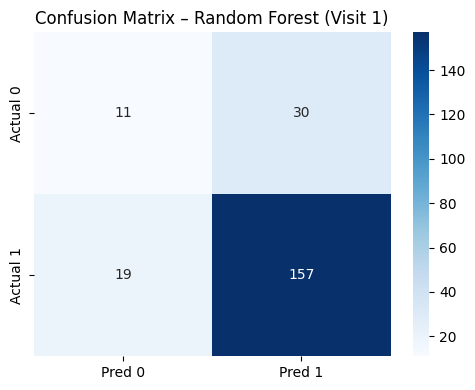

=== Top 20 Features – Random Forest ===
            feature  importance
  Treatment_present    0.088347
          cerv_flex    0.087305
         l_cerv_rot    0.076212
         l_lat_flex    0.052435
  import_phq9_score    0.052000
         r_cerv_rot    0.049726
     bess_single_ec    0.045287
        subocc_flex    0.042654
         subocc_ext    0.042016
  import_gad7_score    0.037180
           cerv_ext    0.034851
         r_lat_flex    0.034476
        npc_measure    0.034362
     bess_tandem_ec    0.031266
 vor_vert_dizziness    0.028451
     vmst_dizziness    0.025327
vor_horiz_dizziness    0.020949
 vor_horiz_headache    0.017898
vor_horiz_fogginess    0.017051
        vmst_nausea    0.017050


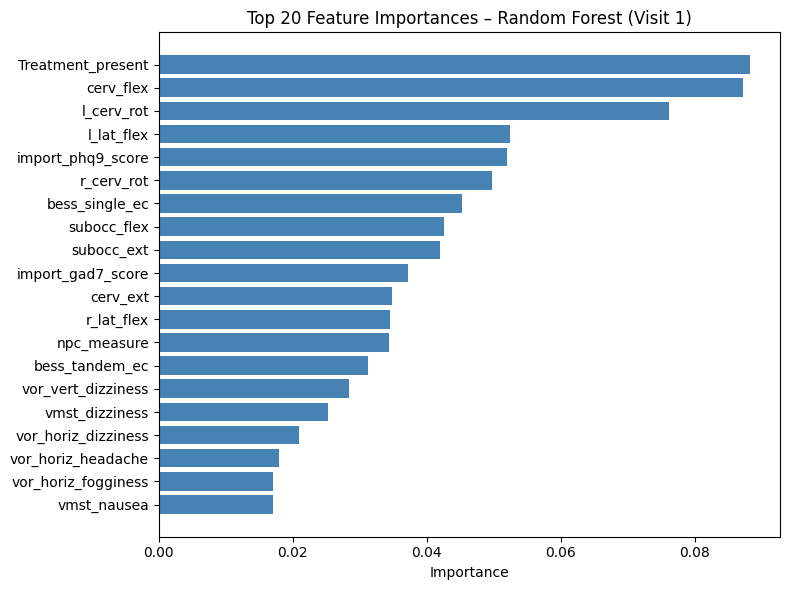

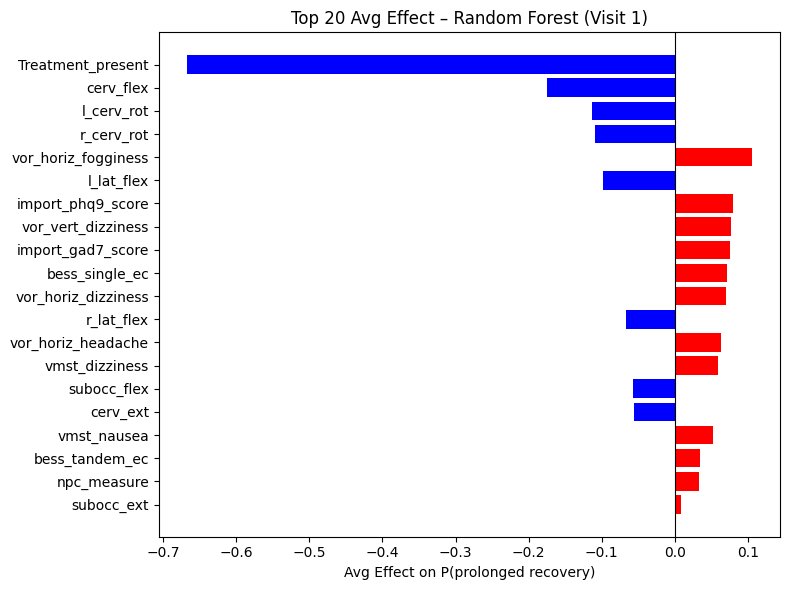

,feature,avg_effect
0,Treatment_present,-0.667330
1,cerv_flex,-0.174611
2,l_cerv_rot,-0.112866
5,r_cerv_rot,-0.108758
18,vor_horiz_fogginess,0.105100
3,l_lat_flex,-0.098251
4,import_phq9_score,0.079347
14,vor_vert_dizziness,0.076876
9,import_gad7_score,0.075376
6,bess_single_ec,0.071452


In [21]:
plot_confusion(y_true_rf, y_pred_rf, "Confusion Matrix – Random Forest (Visit 1)")
fi_df_rf = (pd.DataFrame({"feature": X_rf.columns, "importance": fi_sum_rf / len(df)})
             .sort_values("importance", ascending=False))
print("=== Top 20 Features – Random Forest ===")
print(fi_df_rf.head(20).to_string(index=False))
top20_rf = plot_feature_importance(fi_df_rf, "Top 20 Feature Importances – Random Forest (Visit 1)")
_m_rf = RandomForestClassifier(random_state=42, class_weight="balanced", **best_params_rf).fit(X_rf, y_rf)
plot_effect_direction(_m_rf, X_rf, top20_rf, "Top 20 Avg Effect – Random Forest (Visit 1)")


## XGBoost

In [22]:
from xgboost import XGBClassifier

X_xgb = df.drop(columns=cols_X)
y_xgb = df["buckets"]
X_tr, X_te, y_tr, y_te = train_test_split(X_xgb, y_xgb, test_size=0.2, random_state=42)

param_dist_xgb = {
    "max_depth":        [3, 5, 7],
    "learning_rate":    [0.05, 0.1, 0.2],
    "subsample":        [0.7, 0.85, 1.0],
    "n_estimators":     [50, 100, 150],
    "colsample_bytree": [0.7, 0.85, 1.0],
    "gamma":            [0, 0.1, 0.3],
    "min_child_weight": [1, 3, 5],
    "reg_alpha":        [0, 0.1, 0.5],
    "reg_lambda":       [0.5, 1.0, 1.5],
}
param_list_xgb = list(ParameterSampler(param_dist_xgb, n_iter=50, random_state=42))
best_score_xgb, best_params_xgb = 0, None
for params in param_list_xgb:
    m = XGBClassifier(random_state=42, scale_pos_weight=scale_pos_weight_val,
                      eval_metric="logloss", verbosity=0, **params)
    m.fit(X_tr, y_tr)
    acc = balanced_accuracy_score(y_te, m.predict(X_te))
    if acc > best_score_xgb:
        best_score_xgb = acc
        best_params_xgb = params
print("Best params:", best_params_xgb)
print(f"Best balanced accuracy: {best_score_xgb:.4f}")


Best params: {'subsample': 0.7, 'reg_lambda': 1.5, 'reg_alpha': 0, 'n_estimators': 150, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.2, 'gamma': 0, 'colsample_bytree': 0.85}
Best balanced accuracy: 0.7083


In [23]:
y_true_xgb, y_pred_xgb, y_prob_xgb = [], [], []
importance_accum_xgb = pd.DataFrame(0.0, index=X_xgb.columns, columns=["importance"])
for i in range(len(df)):
    Xtr = X_xgb.drop(index=i)
    ytr = y_xgb.drop(index=i)
    Xte = X_xgb.iloc[[i]]
    m = XGBClassifier(random_state=42, scale_pos_weight=scale_pos_weight_val,
                      eval_metric="logloss", verbosity=0, **best_params_xgb)
    m.fit(Xtr, ytr)
    fold_imp = m.get_booster().get_score(importance_type="gain")
    for feat, score in fold_imp.items():
        if feat in importance_accum_xgb.index:
            importance_accum_xgb.loc[feat, "importance"] += score
    y_pred_xgb.append(m.predict(Xte)[0])
    y_prob_xgb.append(m.predict_proba(Xte)[0, 1])
    y_true_xgb.append(y_xgb.iloc[i])
    if (i + 1) % 50 == 0 or (i + 1) == len(df):
        print(f"Progress: {i+1}/{len(df)}")
y_true_xgb, y_pred_xgb, y_prob_xgb = np.array(y_true_xgb), np.array(y_pred_xgb), np.array(y_prob_xgb)
print("=== XGBoost LOOCV Results (Visit 1) ===")
metrics_xgb, cis_xgb = compute_metrics(y_true_xgb, y_pred_xgb, y_prob_xgb)


Progress: 50/217
Progress: 100/217
Progress: 150/217
Progress: 200/217
Progress: 217/217
=== XGBoost LOOCV Results (Visit 1) ===
Metric               Point Est   95% CI
------------------------------------------------
accuracy             0.7972      [0.7419, 0.8479]
bal_accuracy         0.6411      [0.5648, 0.7215]
precision            0.8626      [0.8102, 0.9101]
recall               0.8920      [0.8461, 0.9364]
f1                   0.8771      [0.8367, 0.9091]
specificity          0.3902      [0.2424, 0.5320]
mcc                  0.3005      [0.1454, 0.4598]
brier                0.1662      [0.1323, 0.2047]


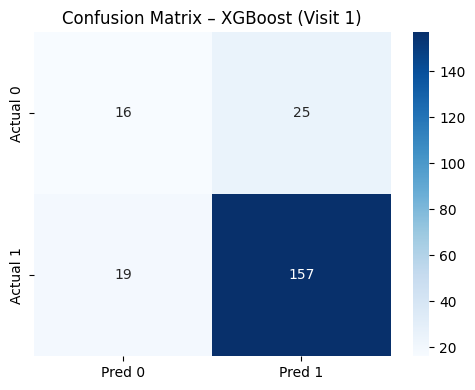

=== Top 20 Features – XGBoost ===
                 feature  importance
       Treatment_present         0.0
 smoothpursuits_headache         0.0
             vmst_nausea         0.0
          vmst_dizziness         0.0
      vor_vert_fogginess         0.0
      vor_vert_dizziness         0.0
       vor_vert_headache         0.0
     vor_horiz_fogginess         0.0
     vor_horiz_dizziness         0.0
      vor_horiz_headache         0.0
             npc_measure         0.0
            npc_headache         0.0
 saccades_vert_dizziness         0.0
saccades_horiz_fogginess         0.0
 saccades_horiz_headache         0.0
smoothpursuits_dizziness         0.0
             voms_nausea         0.0
        prev_head_injury         0.0
          voms_dizziness         0.0
           voms_headache         0.0


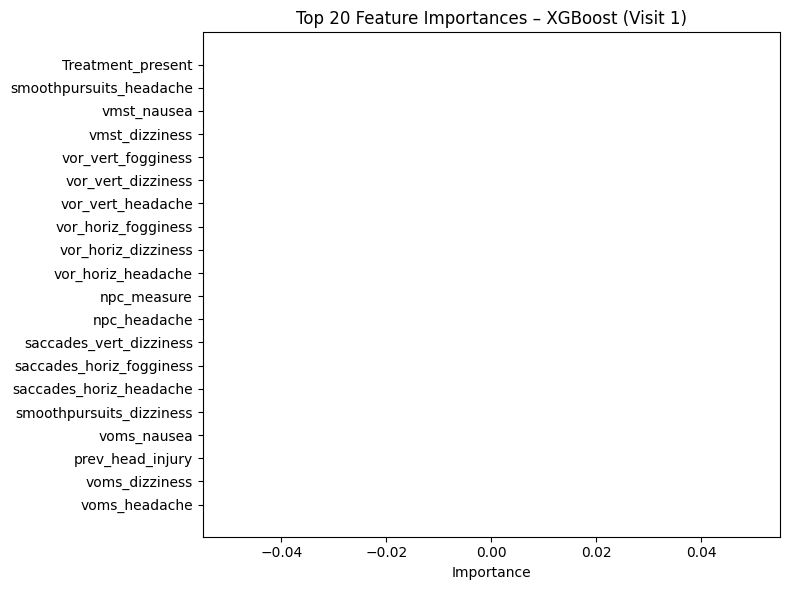

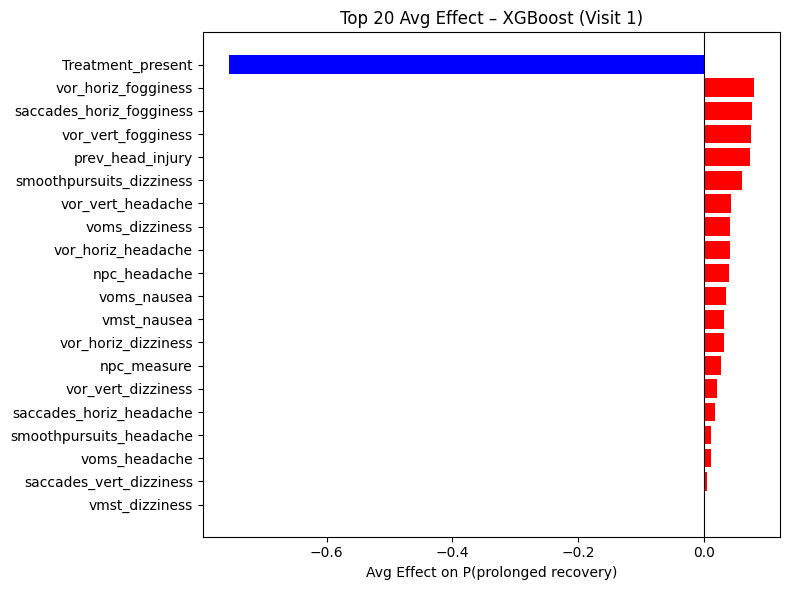

,feature,avg_effect
0,Treatment_present,-0.755943
7,vor_horiz_fogginess,0.079531
13,saccades_horiz_fogginess,0.076521
4,vor_vert_fogginess,0.075380
17,prev_head_injury,0.072922
15,smoothpursuits_dizziness,0.060032
6,vor_vert_headache,0.043743
18,voms_dizziness,0.042214
9,vor_horiz_headache,0.041281
11,npc_headache,0.040674


In [24]:
plot_confusion(y_true_xgb, y_pred_xgb, "Confusion Matrix – XGBoost (Visit 1)")
importance_accum_xgb["importance"] /= len(df)
fi_df_xgb = (importance_accum_xgb.reset_index().rename(columns={"index": "feature"})
              .sort_values("importance", ascending=False))
print("=== Top 20 Features – XGBoost ===")
print(fi_df_xgb.head(20).to_string(index=False))
top20_xgb = plot_feature_importance(fi_df_xgb, "Top 20 Feature Importances – XGBoost (Visit 1)")
_m_xgb = XGBClassifier(random_state=42, scale_pos_weight=scale_pos_weight_val,
                        eval_metric="logloss", verbosity=0, **best_params_xgb).fit(X_xgb, y_xgb)
plot_effect_direction(_m_xgb, X_xgb, top20_xgb, "Top 20 Avg Effect – XGBoost (Visit 1)")


In [40]:
y_true_xgb, y_pred_xgb, y_prob_xgb = [], [], []
importance_accum_xgb = pd.DataFrame(0.0, index=X_xgb.columns, columns=["importance"])

# Specify importance_type in the constructor to ensure 'gain' is used
_xgb_model = XGBClassifier(
    random_state=42, 
    scale_pos_weight=scale_pos_weight_val,
    eval_metric="logloss", 
    verbosity=0, 
    importance_type="gain", # Explicitly set importance type
    **best_params_xgb
)

X_xgb = X_xgb.reset_index(drop=True)
y_xgb = y_xgb.reset_index(drop=True)

for i in range(len(df)):
    Xtr = X_xgb.drop(i)
    ytr = y_xgb.drop(i)
    Xte = X_xgb.iloc[[i]]

    _xgb_model.fit(Xtr, ytr)

    # FIX: Use feature_importances_ which aligns with X_xgb.columns
    importance_accum_xgb["importance"] += _xgb_model.feature_importances_

    y_pred_xgb.append(_xgb_model.predict(Xte)[0])
    y_prob_xgb.append(_xgb_model.predict_proba(Xte)[0, 1])
    y_true_xgb.append(y_xgb.iloc[i])

    if (i + 1) % 50 == 0 or (i + 1) == len(df):
        print(f"Progress: {i+1}/{len(df)}")

y_true_xgb, y_pred_xgb, y_prob_xgb = np.array(y_true_xgb), np.array(y_pred_xgb), np.array(y_prob_xgb)

# Calculate average importance and sort
importance_accum_xgb["importance"] /= len(df)
importance_table = importance_accum_xgb.sort_values(by="importance", ascending=False)

print("=== XGBoost LOOCV Results (Visit 1) ===")
metrics_xgb, cis_xgb = compute_metrics(y_true_xgb, y_pred_xgb, y_prob_xgb)

print("\n=== XGBoost Feature Importance (Average Gain) ===")
importance_table.head(20)

Progress: 50/217
Progress: 100/217
Progress: 150/217
Progress: 200/217
Progress: 217/217
=== XGBoost LOOCV Results (Visit 1) ===
Metric               Point Est   95% CI
------------------------------------------------
accuracy             0.7972      [0.7419, 0.8479]
bal_accuracy         0.6411      [0.5648, 0.7215]
precision            0.8626      [0.8102, 0.9101]
recall               0.8920      [0.8461, 0.9364]
f1                   0.8771      [0.8367, 0.9091]
specificity          0.3902      [0.2424, 0.5320]
mcc                  0.3005      [0.1454, 0.4598]
brier                0.1662      [0.1323, 0.2047]

=== XGBoost Feature Importance (Average Gain) ===


,importance
Treatment_present,0.092577
cerv_flex,0.046078
smoothpursuits_headache,0.044205
voms_dizziness,0.043564
l_cerv_rot,0.042364
bess_tandem_ec,0.037576
vor_horiz_dizziness,0.037143
import_phq9_score,0.035530
bess_single_ec,0.032566
voms_headache,0.031980


## SVC

In [25]:
from sklearn.svm import SVC

X_svc = df.drop(columns=cols_X)
y_svc = df["buckets"]
X_tr, X_te, y_tr, y_te = train_test_split(X_svc, y_svc, test_size=0.2, random_state=42)

param_dist_svc = {
    "C":      [0.1, 1, 10, 100],
    "gamma":  [1, 0.1, 0.01, 0.0001],
    "kernel": ["linear", "rbf", "poly"],
}
param_list_svc = list(ParameterSampler(param_dist_svc, n_iter=50, random_state=42))
best_score_svc, best_params_svc = 0, None
for params in param_list_svc:
    m = SVC(random_state=42, class_weight="balanced", **params)
    m.fit(X_tr, y_tr)
    acc = balanced_accuracy_score(y_te, m.predict(X_te))
    if acc > best_score_svc:
        best_score_svc = acc
        best_params_svc = params
print("Best params:", best_params_svc)
print(f"Best balanced accuracy: {best_score_svc:.4f}")


Best params: {'kernel': 'rbf', 'gamma': 0.0001, 'C': 1}
Best balanced accuracy: 0.7847


In [26]:
y_true_svc, y_pred_svc, y_prob_svc = [], [], []
fi_sum_svc = np.zeros(X_svc.shape[1])
for i in range(len(df)):
    Xtr = X_svc.drop(index=i)
    ytr = y_svc.drop(index=i)
    Xte = X_svc.iloc[[i]]
    m = SVC(random_state=42, class_weight="balanced", probability=True, **best_params_svc)
    m.fit(Xtr, ytr)
    if best_params_svc.get("kernel") == "linear":
        fi_sum_svc += np.abs(m.coef_).flatten()
    y_pred_svc.append(m.predict(Xte)[0])
    y_prob_svc.append(m.predict_proba(Xte)[0, 1])
    y_true_svc.append(y_svc.iloc[i])
    if (i + 1) % 50 == 0 or (i + 1) == len(df):
        print(f"Progress: {i+1}/{len(df)}")
y_true_svc, y_pred_svc, y_prob_svc = np.array(y_true_svc), np.array(y_pred_svc), np.array(y_prob_svc)
print("=== SVC LOOCV Results (Visit 1) ===")
metrics_svc, cis_svc = compute_metrics(y_true_svc, y_pred_svc, y_prob_svc)


Progress: 50/217
Progress: 100/217
Progress: 150/217
Progress: 200/217
Progress: 217/217
=== SVC LOOCV Results (Visit 1) ===
Metric               Point Est   95% CI
------------------------------------------------
accuracy             0.5668      [0.5023, 0.6267]
bal_accuracy         0.6207      [0.5417, 0.6957]
precision            0.8868      [0.8269, 0.9388]
recall               0.5341      [0.4590, 0.6035]
f1                   0.6667      [0.6022, 0.7236]
specificity          0.7073      [0.5713, 0.8421]
mcc                  0.1891      [0.0645, 0.3101]
brier                0.1545      [0.1241, 0.1886]


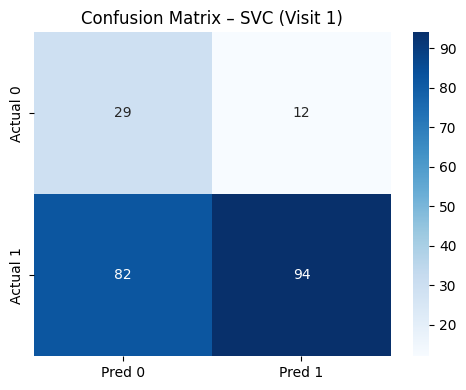

=== Top 20 Features – SVC ===
                 feature  importance
               cerv_flex    0.098961
              r_cerv_rot    0.038522
       import_phq9_score    0.036679
              l_cerv_rot    0.028056
                cerv_ext    0.017600
              r_lat_flex    0.011093
              l_lat_flex    0.010969
              subocc_ext    0.006759
saccades_horiz_fogginess    0.003250
      vor_vert_fogginess    0.002740
     vor_horiz_fogginess    0.002740
          vmst_fogginess    0.002740
       import_gad7_score    0.002131
          bess_single_ec    0.000734
             subocc_flex    0.000142
 saccades_vert_dizziness    0.000142
          vmst_dizziness    0.000000
       vor_vert_headache    0.000000
     vor_horiz_dizziness    0.000000
      vor_horiz_headache    0.000000


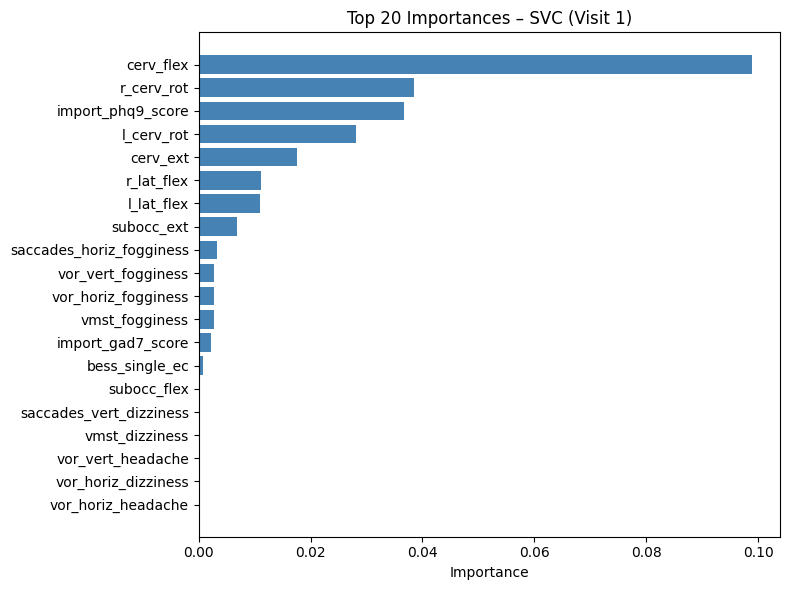

In [27]:
plot_confusion(y_true_svc, y_pred_svc, "Confusion Matrix – SVC (Visit 1)")
if best_params_svc.get("kernel") == "linear":
    fi_df_svc = (pd.DataFrame({"feature": X_svc.columns, "importance": fi_sum_svc / len(df)})
                 .sort_values("importance", ascending=False))
else:
    from sklearn.inspection import permutation_importance as perm_imp
    _m_svc = SVC(random_state=42, class_weight="balanced", probability=True,
                 **best_params_svc).fit(X_svc, y_svc)
    perm = perm_imp(_m_svc, X_svc, y_svc, scoring="balanced_accuracy",
                    n_repeats=20, random_state=42, n_jobs=-1)
    fi_df_svc = (pd.DataFrame({"feature": X_svc.columns, "importance": perm.importances_mean})
                 .sort_values("importance", ascending=False))
print("=== Top 20 Features – SVC ===")
print(fi_df_svc.head(20).to_string(index=False))
top20_svc = plot_feature_importance(fi_df_svc, "Top 20 Importances – SVC (Visit 1)")


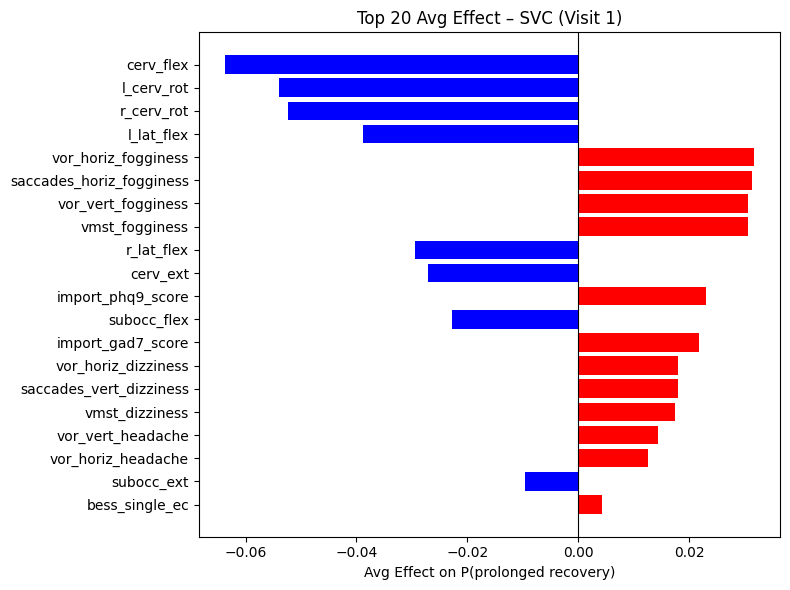

In [32]:
# Average effect plot – SVC
# Uses predict_proba (probability=True was set during LOOCV)
_m_svc = SVC(random_state=42, class_weight="balanced", probability=True,
             **best_params_svc).fit(X_svc, y_svc)

top_feats_svc = top20_svc["feature"].tolist()
effects_svc = []
for f in top_feats_svc:
    med = X_svc[f].median()
    X_hi = X_svc[X_svc[f] > med]
    X_lo = X_svc[X_svc[f] <= med]
    ph = _m_svc.predict_proba(X_hi)[:, 1].mean() if not X_hi.empty else 0.0
    pl = _m_svc.predict_proba(X_lo)[:, 1].mean() if not X_lo.empty else 0.0
    effects_svc.append({"feature": f, "avg_effect": ph - pl})

eff_svc = pd.DataFrame(effects_svc).sort_values("avg_effect", key=abs, ascending=False)
colors = eff_svc["avg_effect"].apply(lambda v: "red" if v > 0 else "blue")
plt.figure(figsize=(8, 6))
plt.barh(eff_svc["feature"], eff_svc["avg_effect"], color=colors)
plt.xlabel("Avg Effect on P(prolonged recovery)")
plt.axvline(0, color="black", lw=0.8)
plt.title("Top 20 Avg Effect – SVC (Visit 1)")  # change to Visit 1 as needed
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Ridge Classifier

In [28]:
from sklearn.linear_model import RidgeClassifier
from sklearn.model_selection import cross_val_score

X_rg = df.drop(columns=cols_X)
y_rg = df["buckets"]

alphas = [0.001, 0.01, 0.1, 1, 5, 10, 15, 20]
best_alpha_rg, best_score_rg = None, -np.inf
for alpha in alphas:
    m = RidgeClassifier(alpha=alpha, class_weight="balanced")
    scores = cross_val_score(m, X_rg, y_rg, cv=10, scoring="balanced_accuracy")
    if scores.mean() > best_score_rg:
        best_score_rg = scores.mean()
        best_alpha_rg = alpha
print(f"Best alpha: {best_alpha_rg}")
print(f"Best CV balanced accuracy: {best_score_rg:.4f}")


Best alpha: 20
Best CV balanced accuracy: 0.5980


In [29]:
y_true_rg, y_pred_rg, y_prob_rg = [], [], []
fi_sum_rg = np.zeros(X_rg.shape[1])
for i in range(len(df)):
    Xtr = X_rg.drop(index=i)
    ytr = y_rg.drop(index=i)
    Xte = X_rg.iloc[[i]]
    m = RidgeClassifier(alpha=best_alpha_rg, class_weight="balanced")
    m.fit(Xtr, ytr)
    fi_sum_rg += np.abs(m.coef_).flatten()
    pred = m.predict(Xte)[0]
    dec = m.decision_function(Xte)[0]
    prob = 1 / (1 + np.exp(-dec))
    y_pred_rg.append(pred)
    y_prob_rg.append(prob)
    y_true_rg.append(y_rg.iloc[i])
    if (i + 1) % 50 == 0 or (i + 1) == len(df):
        print(f"Progress: {i+1}/{len(df)}")
y_true_rg, y_pred_rg, y_prob_rg = np.array(y_true_rg), np.array(y_pred_rg), np.array(y_prob_rg)
print("=== Ridge Classifier LOOCV Results (Visit 1) ===")
metrics_rg, cis_rg = compute_metrics(y_true_rg, y_pred_rg, y_prob_rg)


Progress: 50/217
Progress: 100/217
Progress: 150/217
Progress: 200/217
Progress: 217/217
=== Ridge Classifier LOOCV Results (Visit 1) ===
Metric               Point Est   95% CI
------------------------------------------------
accuracy             0.6221      [0.5576, 0.6820]
bal_accuracy         0.5893      [0.4955, 0.6704]
precision            0.8561      [0.7926, 0.9078]
recall               0.6420      [0.5747, 0.7118]
f1                   0.7338      [0.6760, 0.7844]
specificity          0.5366      [0.3749, 0.6786]
mcc                  0.1433      [-0.0068, 0.2787]
brier                0.2301      [0.2169, 0.2442]


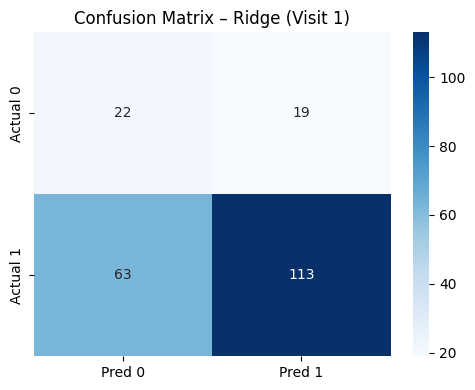

=== Top 20 Features – Ridge ===
                 feature  importance
       Treatment_present    0.468744
saccades_horiz_fogginess    0.153119
 saccades_vert_dizziness    0.145123
smoothpursuits_dizziness    0.129832
      vor_vert_dizziness    0.110844
          vmst_dizziness    0.104751
          bess_single_ec    0.096206
     vor_horiz_fogginess    0.060291
          vmst_fogginess    0.055560
      vor_vert_fogginess    0.038106
 saccades_horiz_headache    0.037982
        prev_head_injury    0.037262
              r_lat_flex    0.036119
            npc_headache    0.031757
       vor_vert_headache    0.029377
       import_phq9_score    0.023971
              l_lat_flex    0.023968
           voms_headache    0.022629
          voms_dizziness    0.021614
               cerv_flex    0.016949


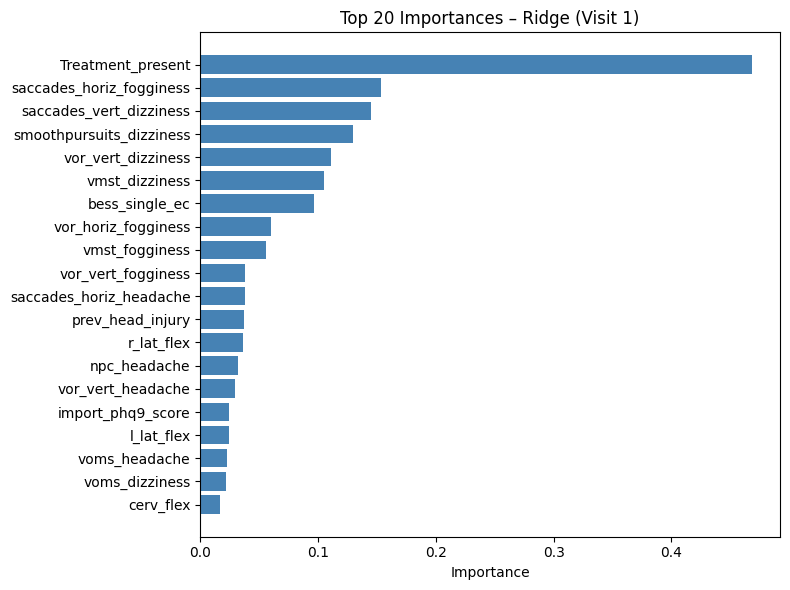

In [30]:
plot_confusion(y_true_rg, y_pred_rg, "Confusion Matrix – Ridge (Visit 1)")
fi_df_rg = (pd.DataFrame({"feature": X_rg.columns, "importance": fi_sum_rg / len(df)})
             .sort_values("importance", ascending=False))
print("=== Top 20 Features – Ridge ===")
print(fi_df_rg.head(20).to_string(index=False))
top20_rg = plot_feature_importance(fi_df_rg, "Top 20 Importances – Ridge (Visit 1)")


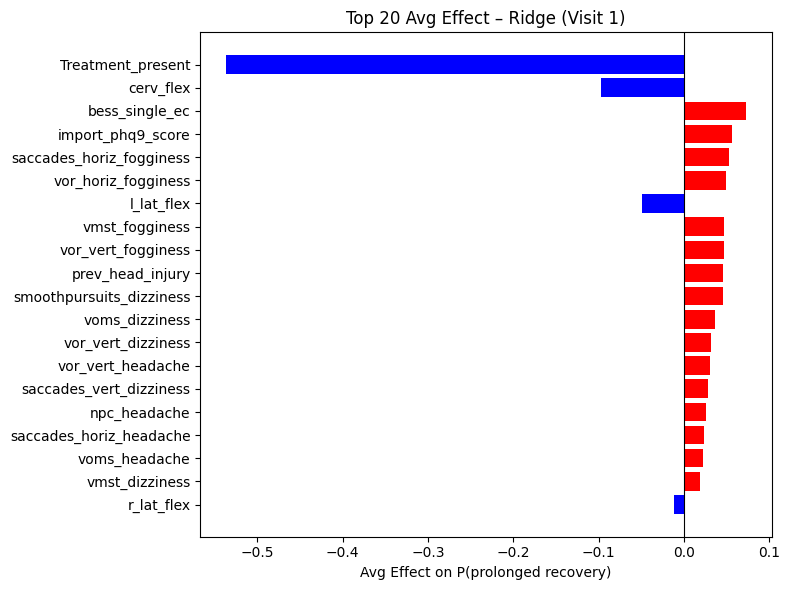

In [33]:
# Average effect plot – Ridge
# Uses sigmoid-transformed decision function as probability proxy
_m_rg = RidgeClassifier(alpha=best_alpha_rg, class_weight="balanced").fit(X_rg, y_rg)

top_feats_rg = top20_rg["feature"].tolist()
effects_rg = []
for f in top_feats_rg:
    med = X_rg[f].median()
    X_hi = X_rg[X_rg[f] > med]
    X_lo = X_rg[X_rg[f] <= med]

    def dec_to_prob(X_sub):
        if X_sub.empty:
            return 0.0
        dec = _m_rg.decision_function(X_sub)
        return (1 / (1 + np.exp(-dec))).mean()

    effects_rg.append({
        "feature": f,
        "avg_effect": dec_to_prob(X_hi) - dec_to_prob(X_lo)
    })

eff_rg = pd.DataFrame(effects_rg).sort_values("avg_effect", key=abs, ascending=False)
colors = eff_rg["avg_effect"].apply(lambda v: "red" if v > 0 else "blue")
plt.figure(figsize=(8, 6))
plt.barh(eff_rg["feature"], eff_rg["avg_effect"], color=colors)
plt.xlabel("Avg Effect on P(prolonged recovery)")
plt.axvline(0, color="black", lw=0.8)
plt.title("Top 20 Avg Effect – Ridge (Visit 1)")  # change to Visit 1 as needed
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Summary Comparison Table – Visit 1 (Comment 37)

In [34]:
summary_rows = [
    ("LightGBM",       metrics_lgbm, cis_lgbm),
    ("Decision Tree",  metrics_dt,   cis_dt),
    ("Random Forest",  metrics_rf,   cis_rf),
    ("XGBoost",        metrics_xgb,  cis_xgb),
    ("SVC",            metrics_svc,  cis_svc),
    ("Ridge",          metrics_rg,   cis_rg),
]

rows = []
for name, pts, cis in summary_rows:
    row = {"Model": name}
    for k in ["accuracy", "bal_accuracy", "precision", "recall", "f1", "specificity", "mcc", "brier"]:
        if k in pts:
            lo, hi = cis[k]
            row[k] = f"{pts[k]:.3f} [{lo:.3f}, {hi:.3f}]"
        else:
            row[k] = "N/A"
    rows.append(row)

summary_df = pd.DataFrame(rows).set_index("Model")

# Use .style to create a readable, non-text based HTML table (best for Jupyter/Colab)
summary_df.style.set_caption("VISIT 1 – Model Comparison (Point Estimate [95% Bootstrap CI])")

,accuracy,bal_accuracy,precision,recall,f1,specificity,mcc,brier
Model,,,,,,,,
LightGBM,"0.737 [0.682, 0.797]","0.698 [0.620, 0.778]","0.899 [0.849, 0.944]","0.761 [0.699, 0.825]","0.825 [0.779, 0.869]","0.634 [0.488, 0.778]","0.334 [0.200, 0.472]","0.188 [0.172, 0.204]"
Decision Tree,"0.631 [0.571, 0.696]","0.614 [0.536, 0.692]","0.869 [0.805, 0.922]","0.642 [0.570, 0.714]","0.739 [0.682, 0.792]","0.585 [0.439, 0.740]","0.182 [0.056, 0.304]","0.237 [0.197, 0.278]"
Random Forest,"0.774 [0.719, 0.829]","0.580 [0.508, 0.656]","0.840 [0.782, 0.891]","0.892 [0.844, 0.938]","0.865 [0.826, 0.900]","0.268 [0.140, 0.415]","0.182 [0.020, 0.336]","0.168 [0.147, 0.191]"
XGBoost,"0.797 [0.742, 0.848]","0.641 [0.565, 0.721]","0.863 [0.810, 0.910]","0.892 [0.846, 0.936]","0.877 [0.837, 0.909]","0.390 [0.242, 0.532]","0.300 [0.145, 0.460]","0.166 [0.132, 0.205]"
SVC,"0.567 [0.502, 0.627]","0.621 [0.542, 0.696]","0.887 [0.827, 0.939]","0.534 [0.459, 0.603]","0.667 [0.602, 0.724]","0.707 [0.571, 0.842]","0.189 [0.064, 0.310]","0.154 [0.124, 0.189]"
Ridge,"0.622 [0.558, 0.682]","0.589 [0.496, 0.670]","0.856 [0.793, 0.908]","0.642 [0.575, 0.712]","0.734 [0.676, 0.784]","0.537 [0.375, 0.679]","0.143 [-0.007, 0.279]","0.230 [0.217, 0.244]"
